# Resume Classification - Exploratory Data Analysis (EDA)
## Project Overview
- **Objective**: Classify resumes into 4 categories (Peoplesoft, React Developer, SQL Developer, Workday)
- **Total Resumes**: 76
- **Categories**: 4
- **Data Source**: Document files (.docx, .doc,.pdf)

---

In [117]:
!pip install pdfplumber 

In [186]:
import subprocess
import os
import warnings 
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [119]:
# 🔹 LibreOffice executable path
LIBREOFFICE_PATH = r"C:\Program Files\LibreOffice\program\soffice.exe"

# 🔹 Your resumes base folder
BASE_FOLDER = r"C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes"

def convert_doc_to_docx(base_folder):
    for root, dirs, files in os.walk(base_folder):
        for file in files:
            # convert ONLY .doc (not .docx)
            if file.lower().endswith(".doc") and not file.lower().endswith(".docx"):
                doc_path = os.path.join(root, file)

                print(f"Converting: {doc_path}")

                subprocess.run(
                    [
                        LIBREOFFICE_PATH,
                        "--headless",
                        "--convert-to",
                        "docx",
                        doc_path,
                        "--outdir",
                        root
                    ],
                    stdout=subprocess.DEVNULL,
                    stderr=subprocess.DEVNULL
                )

    print("✅ All .doc files converted to .docx successfully")

# Run conversion
convert_doc_to_docx(BASE_FOLDER)

Converting: C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes\Peoplesoft\Peoplesoft Admin_G Ananda Rayudu.doc
Converting: C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes\Peoplesoft\Peoplesoft Admin_Gangareddy.doc
Converting: C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes\Peoplesoft\Peoplesoft Admin_Priyanka Ramadoss.doc
Converting: C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes\Peoplesoft\Peoplesoft Admin_srinivasarao.doc
Converting: C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes\Peoplesoft\Peoplesoft Admin_Vinod Akkala.doc
Converting: C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes\Peoplesoft\PeopleSoft DBA_Ganesh Alladi.doc
Converting: C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes\Peoplesoft\Peoplesoft Finance_Arun Venu.doc
Converting: C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes\Peoplesoft\Peoplesoft Finance_Pritam Bisw

In [120]:
!python -m pip install pdfplumber


In [121]:
!python -m pip show pdfplumber


Name: pdfplumber
Version: 0.11.9
Summary: Plumb a PDF for detailed information about each char, rectangle, and line.
Home-page: https://github.com/jsvine/pdfplumber
Author: Jeremy Singer-Vine
Author-email: jsvine@gmail.com
License: 
Location: C:\Users\sivap\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: pdfminer.six, Pillow, pypdfium2
Required-by: 


In [122]:
import sys
print(sys.executable)


C:\Users\sivap\AppData\Local\Programs\Python\Python311\python.exe


In [123]:
import pdfplumber


In [124]:
!pip install python-docx

In [125]:
import pandas as pd
import re
from docx import Document

In [126]:
def read_docx(file_path):
    doc=Document(file_path)
    text=[]
    for p in doc.paragraphs:
        text.append(p.text)
    return " ".join(text)

In [127]:
def read_pdf(file_path):
    text = ""
    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text
    return text

In [128]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


In [129]:
BASE_PATH = r"C:\Users\sivap\Data Science\Projects\Resumer_Classification\Resumes"

data = []

for label in os.listdir(BASE_PATH):
    label_path = os.path.join(BASE_PATH, label)

    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            file_path = os.path.join(label_path, file)

            try:
                if file.lower().endswith(".docx"):
                    text = read_docx(file_path)

                elif file.lower().endswith(".pdf"):
                    text = read_pdf(file_path)

                else:
                    continue

                data.append({
                    "filename": file,
                    "resume_text": text,
                    "clean_text": clean_text(text),
                    "label": label
                })

            except Exception as e:
                print(f"❌ Error reading {file}: {e}")


In [130]:
df=pd.DataFrame(data)

In [131]:
df.head()

,filename,resume_text,clean_text,label
0,Peoplesoft Admin_AnubhavSingh.docx,Anubhav Kumar Singh\t\t To work in a glob...,anubhav kumar singh to work in a globally comp...,Peoplesoft
1,Peoplesoft Admin_G Ananda Rayudu.docx,\t Profile Summary:\t\t\t\t\t\t\t\t\t\t...,profile summary years of experience in impleme...,Peoplesoft
2,Peoplesoft Admin_Gangareddy.docx,PeopleSoft Database Administrator ...,peoplesoft database administrator gangareddy p...,Peoplesoft
3,Peoplesoft Admin_Murali.docx,Murali Experience Summary I have 6 years of...,murali experience summary i have years of expe...,Peoplesoft
4,Peoplesoft Admin_Priyanka Ramadoss.docx,"Priyanka Ramadoss 61/46, MountPleasant, Coono...",priyanka ramadoss mountpleasant coonoor the ni...,Peoplesoft


In [132]:
df['label'].value_counts()

label
React Js                           24
workday                            21
Peoplesoft                         20
SQL Developer Lightning insight    14
Name: count, dtype: int64

In [133]:
df.shape

(79, 4)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   filename     79 non-null     object
 1   resume_text  79 non-null     object
 2   clean_text   79 non-null     object
 3   label        79 non-null     object
dtypes: object(4)
memory usage: 2.6+ KB


In [135]:
df.describe()

,filename,resume_text,clean_text,label
count,79,79,79,79
unique,79,79,77,4
top,Peoplesoft Admin_AnubhavSingh.docx,Anubhav Kumar Singh\t\t To work in a glob...,mareedu lokesh babu professional overview arou...,React Js
freq,1,1,2,24


In [136]:
df.duplicated().sum()

np.int64(0)

In [137]:
df.isnull().sum()

filename       0
resume_text    0
clean_text     0
label          0
dtype: int64

In [138]:
# Basic statistics
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Total Records: {len(df)}")
print(f"Total Categories: {df['label'].nunique()}")
print(f"Columns: {list(df.columns)}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Records: {df.duplicated().sum()}")

print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)
class_dist = df['label'].value_counts().sort_values(ascending=False)
for category, count in class_dist.items():
    percentage = (count / len(df)) * 100
    print(f"{category:20} : {count:3} resumes ({percentage:5.2f}%)")

print(f"\nBalanced Dataset: {'✓ Yes' if class_dist.std() < 5 else '✗ No - Consider balancing'}")


DATASET OVERVIEW
Total Records: 79
Total Categories: 4
Columns: ['filename', 'resume_text', 'clean_text', 'label']
Missing Values: 0
Duplicate Records: 0

CLASS DISTRIBUTION
React Js             :  24 resumes (30.38%)
workday              :  21 resumes (26.58%)
Peoplesoft           :  20 resumes (25.32%)
SQL Developer Lightning insight :  14 resumes (17.72%)

Balanced Dataset: ✓ Yes


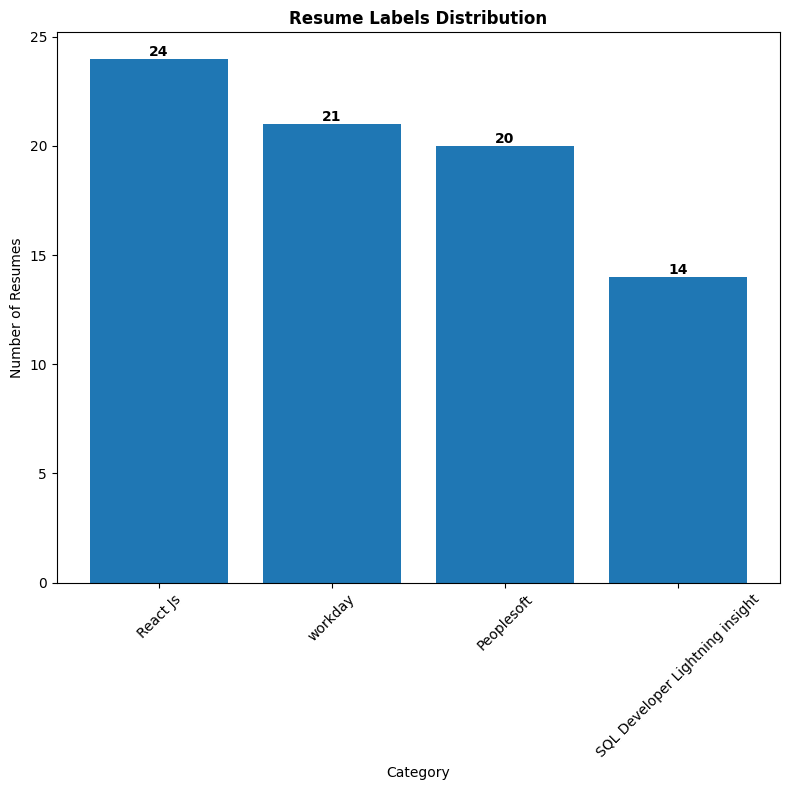

In [139]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
bars=plt.bar(df['label'].value_counts().index,df['label'].value_counts().values)
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             str(height),
             ha='center',
             va='bottom',
             fontweight='bold')

plt.title("Resume Labels Distribution", fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


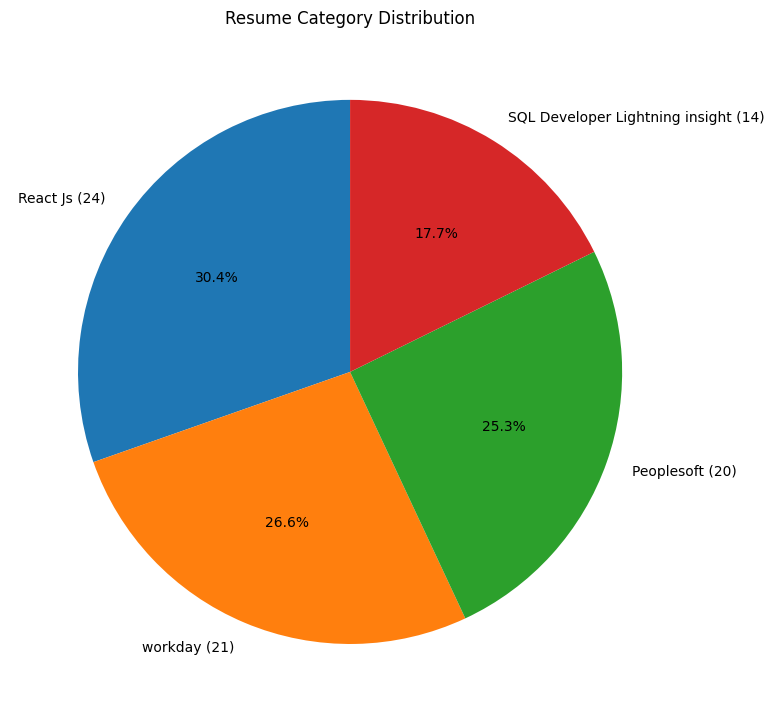

In [140]:
plt.figure(figsize=(8,8))

plt.pie(
    df['label'].value_counts(),
    labels=[f"{cat} ({count})" for cat, count in zip(df['label'].value_counts().index, df['label'].value_counts())],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Resume Category Distribution")
plt.tight_layout()
plt.show()


In [141]:
# Calculate text statistics
df['Text_Length'] = df['clean_text'].apply(len)
df['Word_Count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['Sentence_Count'] = df['clean_text'].apply(lambda x: len(x.split('.')))

# Summary statistics
print("\n" + "="*60)
print("TEXT LENGTH STATISTICS (By Category)")
print("="*60)

stats = df.groupby('label')[['Text_Length', 'Word_Count', 'Sentence_Count']].describe().round(2)
print(stats)

# Overall statistics
print("\n" + "="*60)
print("OVERALL TEXT STATISTICS")
print("="*60)
print(f"Avg. Characters: {df['Text_Length'].mean():.2f}")
print(f"Avg. Words: {df['Word_Count'].mean():.2f}")
print(f"Min. Characters: {df['Text_Length'].min()}")
print(f"Max. Characters: {df['Text_Length'].max()}")


TEXT LENGTH STATISTICS (By Category)
                                Text_Length                            \
                                      count     mean      std     min   
label                                                                   
Peoplesoft                             20.0  5790.05  4344.36  1187.0   
React Js                               24.0  2182.58  1050.54   137.0   
SQL Developer Lightning insight        14.0  3758.36  1577.76  1428.0   
workday                                21.0  5498.67  1857.27  2397.0   

                                                                   Word_Count  \
                                     25%     50%      75%      max      count   
label                                                                           
Peoplesoft                       2684.25  3569.5  7553.25  16742.0       20.0   
React Js                         1404.50  2216.5  2571.75   5160.0       24.0   
SQL Developer Lightning insight  3112.00  365

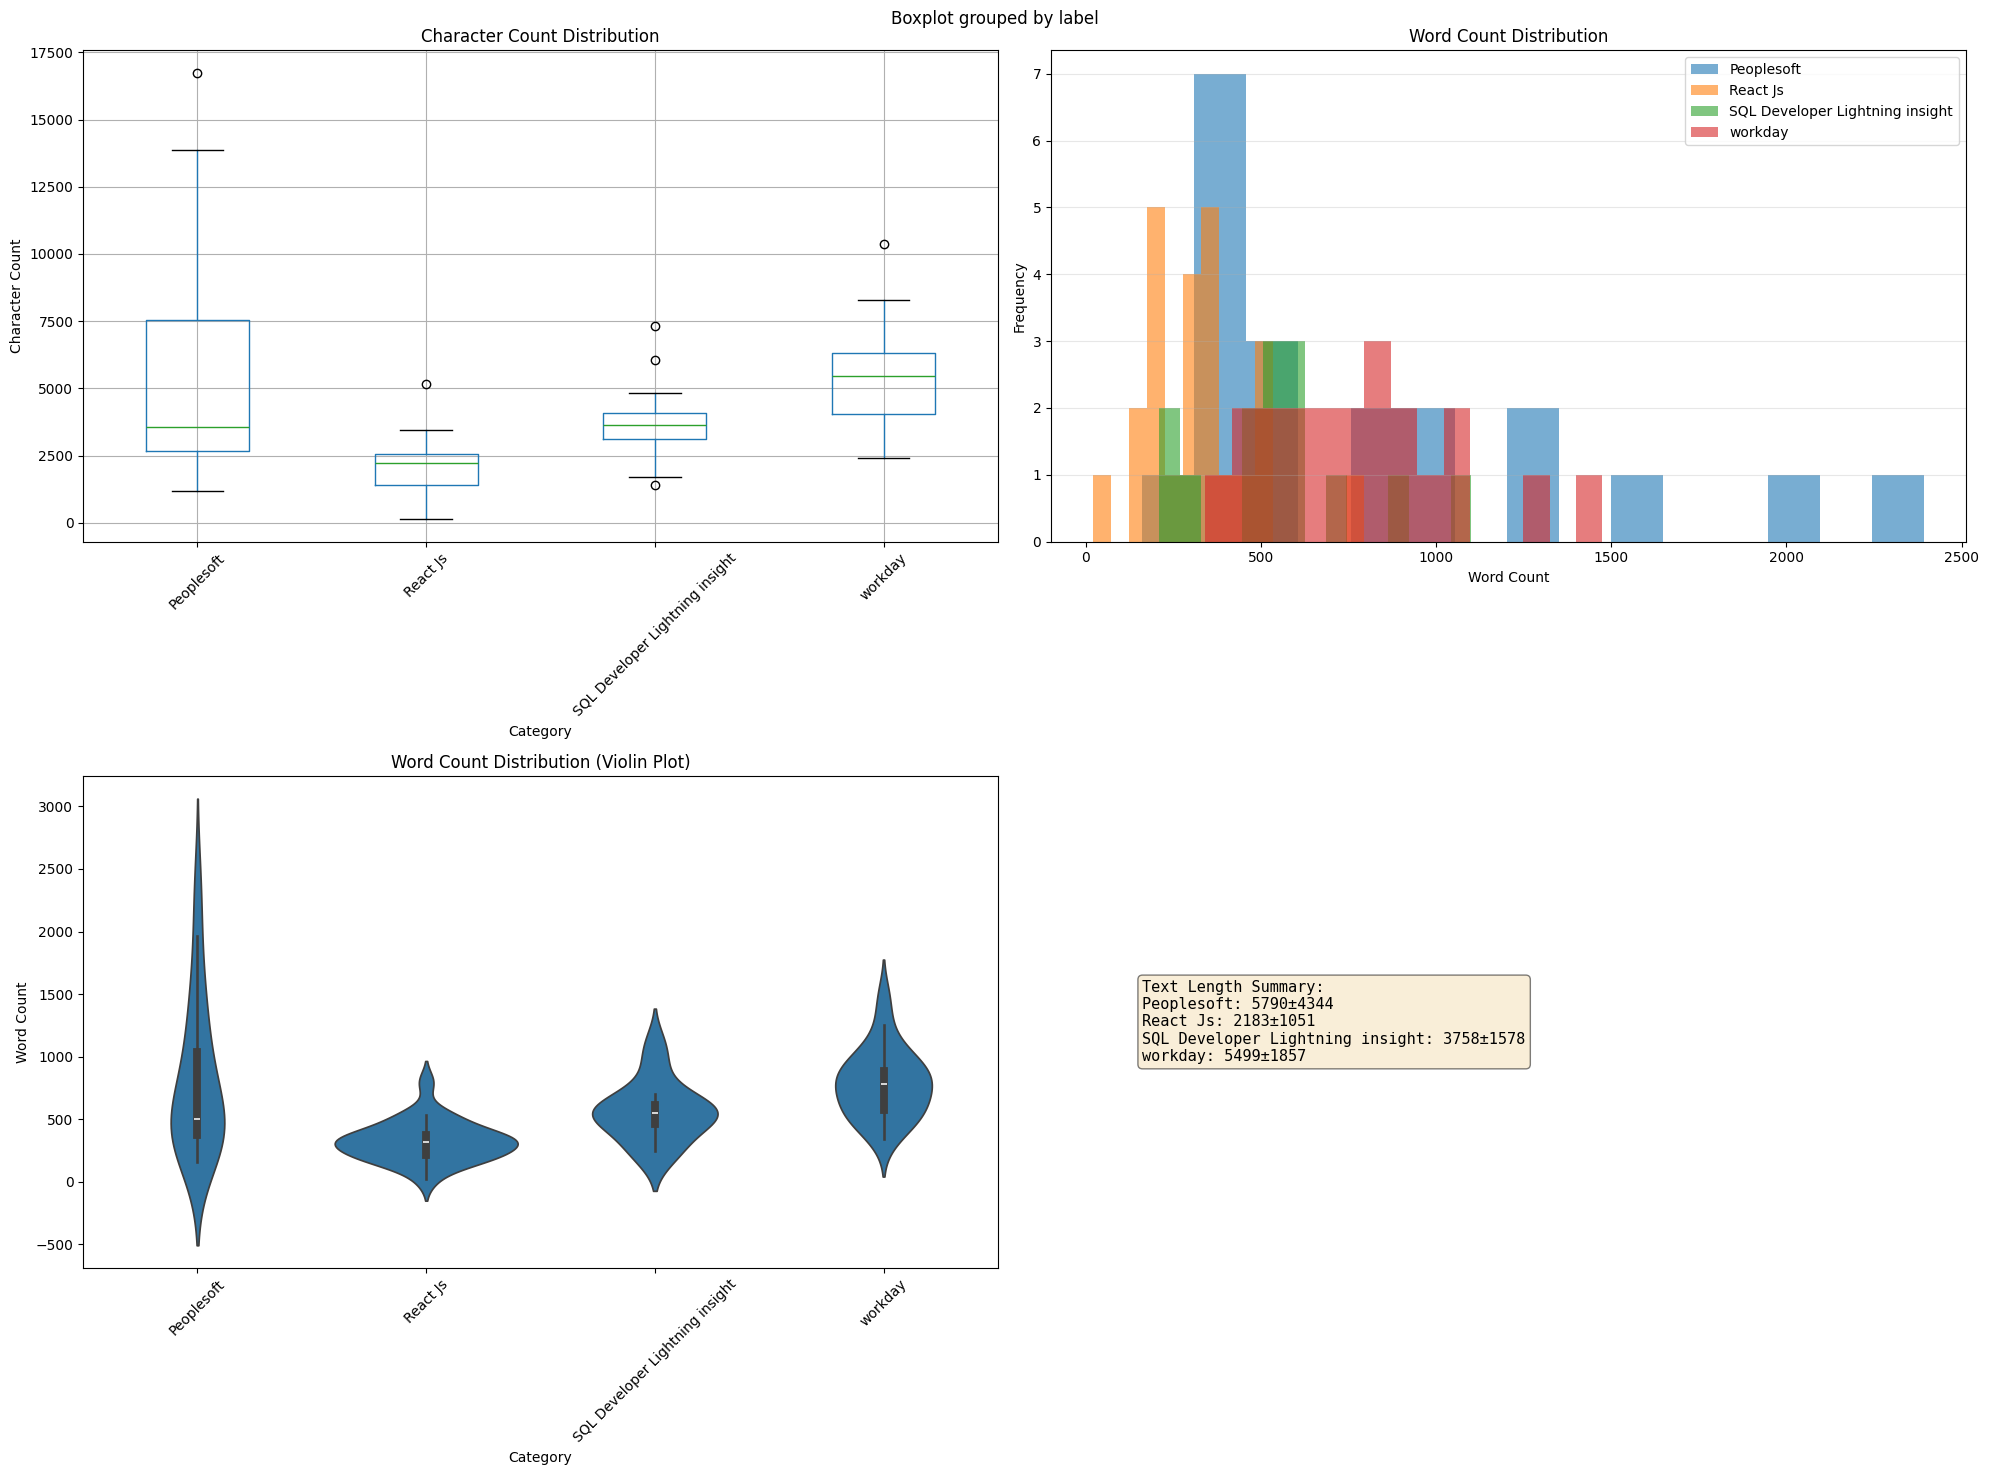

✓ Text length analysis visualization complete!


In [142]:
import seaborn as sns
# Visualization: Distribution of text length by category
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Resume Length Distribution by Category', fontsize=16, fontweight='bold', y=1.00)

# Box plot
ax1 = axes[0, 0]
df.boxplot(column='Text_Length', by='label', ax=ax1)
ax1.set_title('Character Count Distribution')
ax1.set_xlabel('Category')
ax1.set_ylabel('Character Count')
plt.sca(ax1)
plt.xticks(rotation=45)

# Histogram for Word Count
ax2 = axes[0, 1]
for category in df['label'].unique():
    data = df[df['label'] == category]['Word_Count']
    ax2.hist(data, alpha=0.6, label=category, bins=15)
ax2.set_title('Word Count Distribution')
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Violin plot
ax3 = axes[1, 0]
sns.violinplot(data=df, x='label', y='Word_Count', ax=ax3)
ax3.set_title('Word Count Distribution (Violin Plot)')
ax3.set_xlabel('Category')
ax3.set_ylabel('Word Count')
ax3.tick_params(axis='x', rotation=45)

# Statistics by category
ax4 = axes[1, 1]
ax4.axis('off')
stats_text = "Text Length Summary:\n" + "\n".join(
    [f"{cat}: {df[df['label']==cat]['Text_Length'].mean():.0f}±{df[df['label']==cat]['Text_Length'].std():.0f}" 
     for cat in df['label'].unique()]
)
ax4.text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()
print("✓ Text length analysis visualization complete!")

## Text Preprocessing and cleaning

In [143]:
!pip install nltk

In [144]:
!pip install wordcloud

In [145]:
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from wordcloud import WordCloud, STOPWORDS
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter

In [146]:

def preprocess_text(text):
    """
    Comprehensive text preprocessing pipeline:
    1. Convert to lowercase
    2. Remove special characters and digits
    3. Remove extra whitespaces
    4. Remove stopwords
    5. Lemmatization
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespaces
    text = ' '.join(text.split())
    
    # Tokenize
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

# Apply preprocessing
print("🔄 Preprocessing text data...")
df['Cleaned_Details'] = df['clean_text'].apply(preprocess_text)

print("✓ Text preprocessing complete!")
print(f"\nExample - Original text (first 200 chars):\n{df['clean_text'].iloc[0][:200]}")
print(f"\nExample - Cleaned text (first 200 chars):\n{df['Cleaned_Details'].iloc[0][:200]}")

🔄 Preprocessing text data...
✓ Text preprocessing complete!

Example - Original text (first 200 chars):
anubhav kumar singh to work in a globally competitive environment on challenging assignments that shall yield the twin benefits of the job satisfaction and a steady paced professional growth professio

Example - Cleaned text (first 200 chars):
anubhav kumar singh work globally competitive environment challenging assignment shall yield twin benefit job satisfaction steady paced professional growth professional experience current hcl current 


In [147]:
# Calculate cleaned text statistics
df['Cleaned_Length'] = df['Cleaned_Details'].apply(len)
df['Cleaned_Word_Count'] = df['Cleaned_Details'].apply(lambda x: len(x.split()))

print("\n" + "="*60)
print("TEXT REDUCTION AFTER CLEANING")
print("="*60)

reduction = ((df['Text_Length'].sum() - df['Cleaned_Length'].sum()) / df['Text_Length'].sum()) * 100
word_reduction = ((df['Word_Count'].sum() - df['Cleaned_Word_Count'].sum()) / df['Word_Count'].sum()) * 100

print(f"Character reduction: {reduction:.2f}%")
print(f"Word count reduction: {word_reduction:.2f}%")
print(f"\nOriginal avg. words: {df['Word_Count'].mean():.2f}")
print(f"Cleaned avg. words: {df['Cleaned_Word_Count'].mean():.2f}")


TEXT REDUCTION AFTER CLEANING
Character reduction: 16.26%
Word count reduction: 27.41%

Original avg. words: 613.23
Cleaned avg. words: 445.11


In [148]:
import numpy as np
# Top keywords by category
print("\n" + "="*60)
print("TOP KEYWORDS BY CATEGORY")
print("="*60)

vectorizer = CountVectorizer(max_features=500, max_df=0.8, min_df=2)
term_doc_matrix = vectorizer.fit_transform(df['Cleaned_Details'])
feature_names = vectorizer.get_feature_names_out()

for category in sorted(df['label'].unique()):
    category_idx = df[df['label'] == category].index
    category_matrix = term_doc_matrix[category_idx]
    term_freq = np.asarray(category_matrix.sum(axis=0)).ravel()
    top_indices = term_freq.argsort()[-15:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    
    print(f"\n{category}:")
    print(f"  {', '.join(top_terms[:10])}")


TOP KEYWORDS BY CATEGORY

Peoplesoft:
  server, peoplesoft, application, database, process, environment, domain, people, web, report

React Js:
  react, html, cs, application, web, javascript, technology, developer, good, used

SQL Developer Lightning insight:
  sql, data, server, table, report, database, query, function, procedure, business

workday:
  workday, integration, report, business, eib, process, worked, requirement, custom, hcm


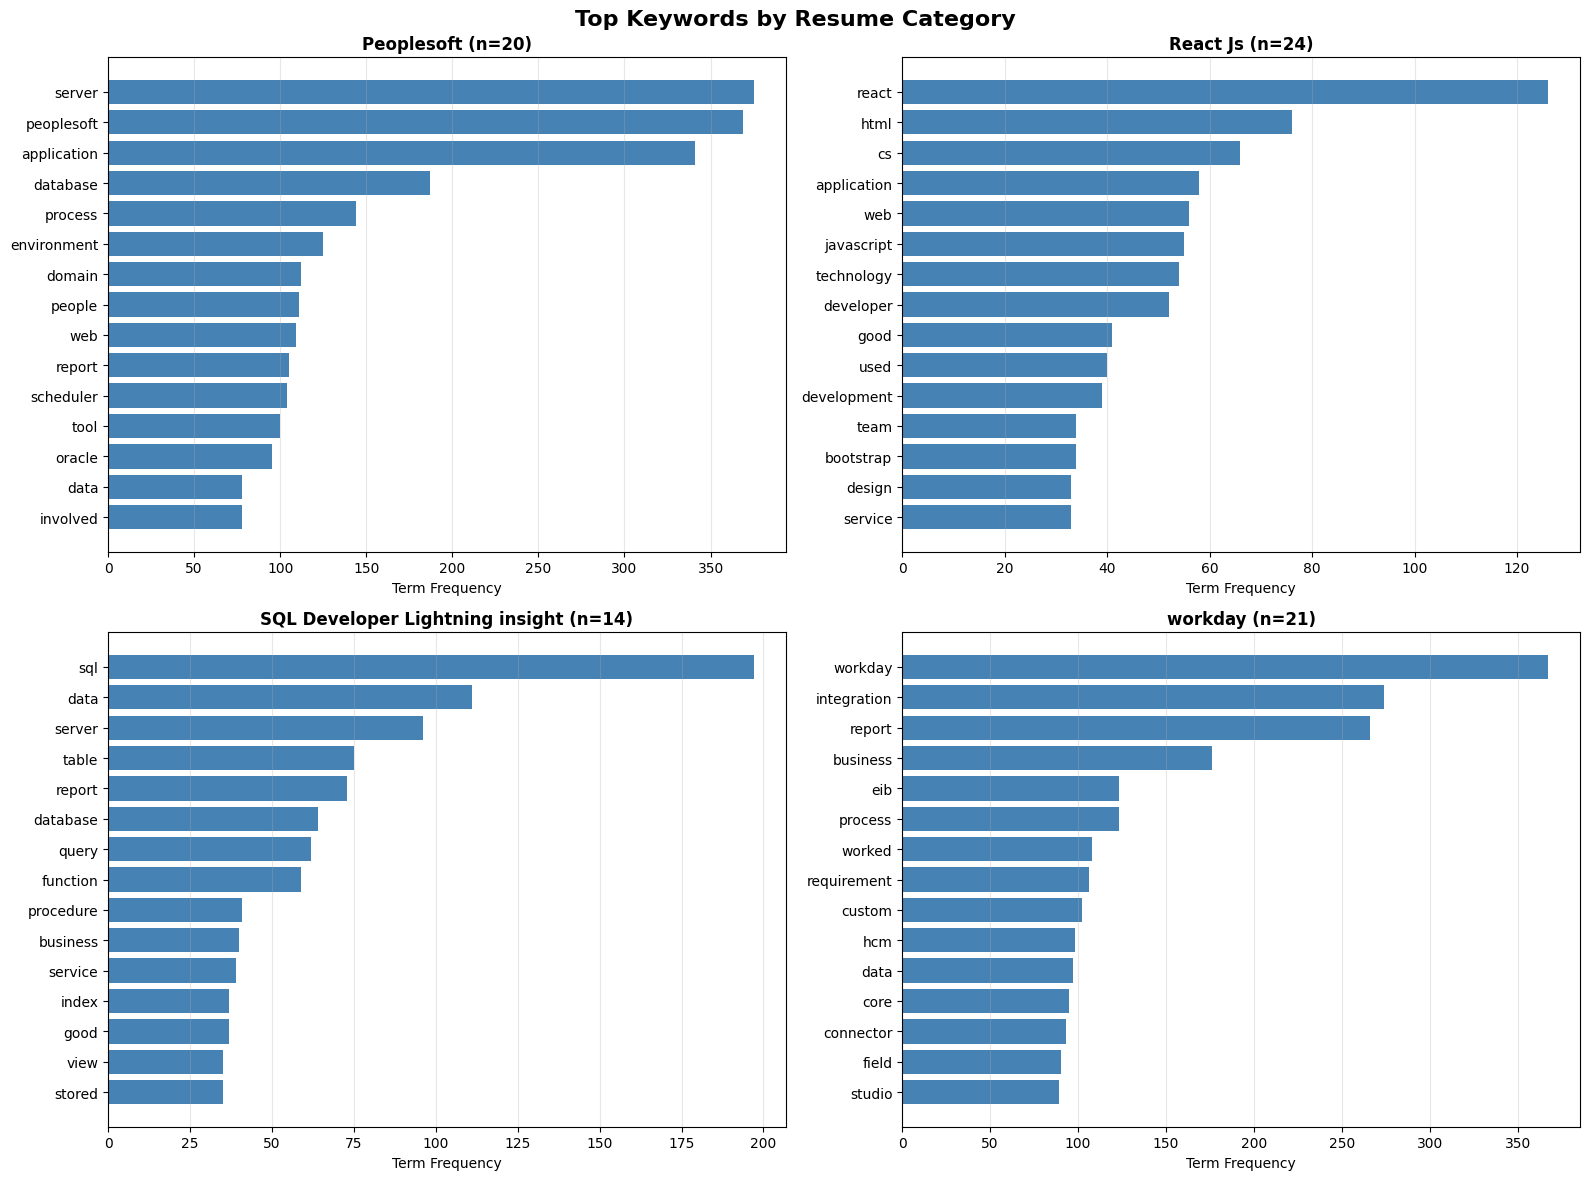

✓ Top keywords visualization complete!


In [149]:
# Detailed top keywords visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top Keywords by Resume Category', fontsize=16, fontweight='bold')

for idx, category in enumerate(sorted(df['label'].unique())):
    ax = axes[idx // 2, idx % 2]
    
    category_idx = df[df['label'] == category].index
    category_matrix = term_doc_matrix[category_idx]
    term_freq = np.asarray(category_matrix.sum(axis=0)).ravel()
    top_indices = term_freq.argsort()[-15:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    top_freqs = term_freq[top_indices]
    
    ax.barh(top_terms, top_freqs, color='steelblue')
    ax.set_title(f'{category} (n={len(category_idx)})', fontweight='bold', fontsize=12)
    ax.set_xlabel('Term Frequency')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Top keywords visualization complete!")

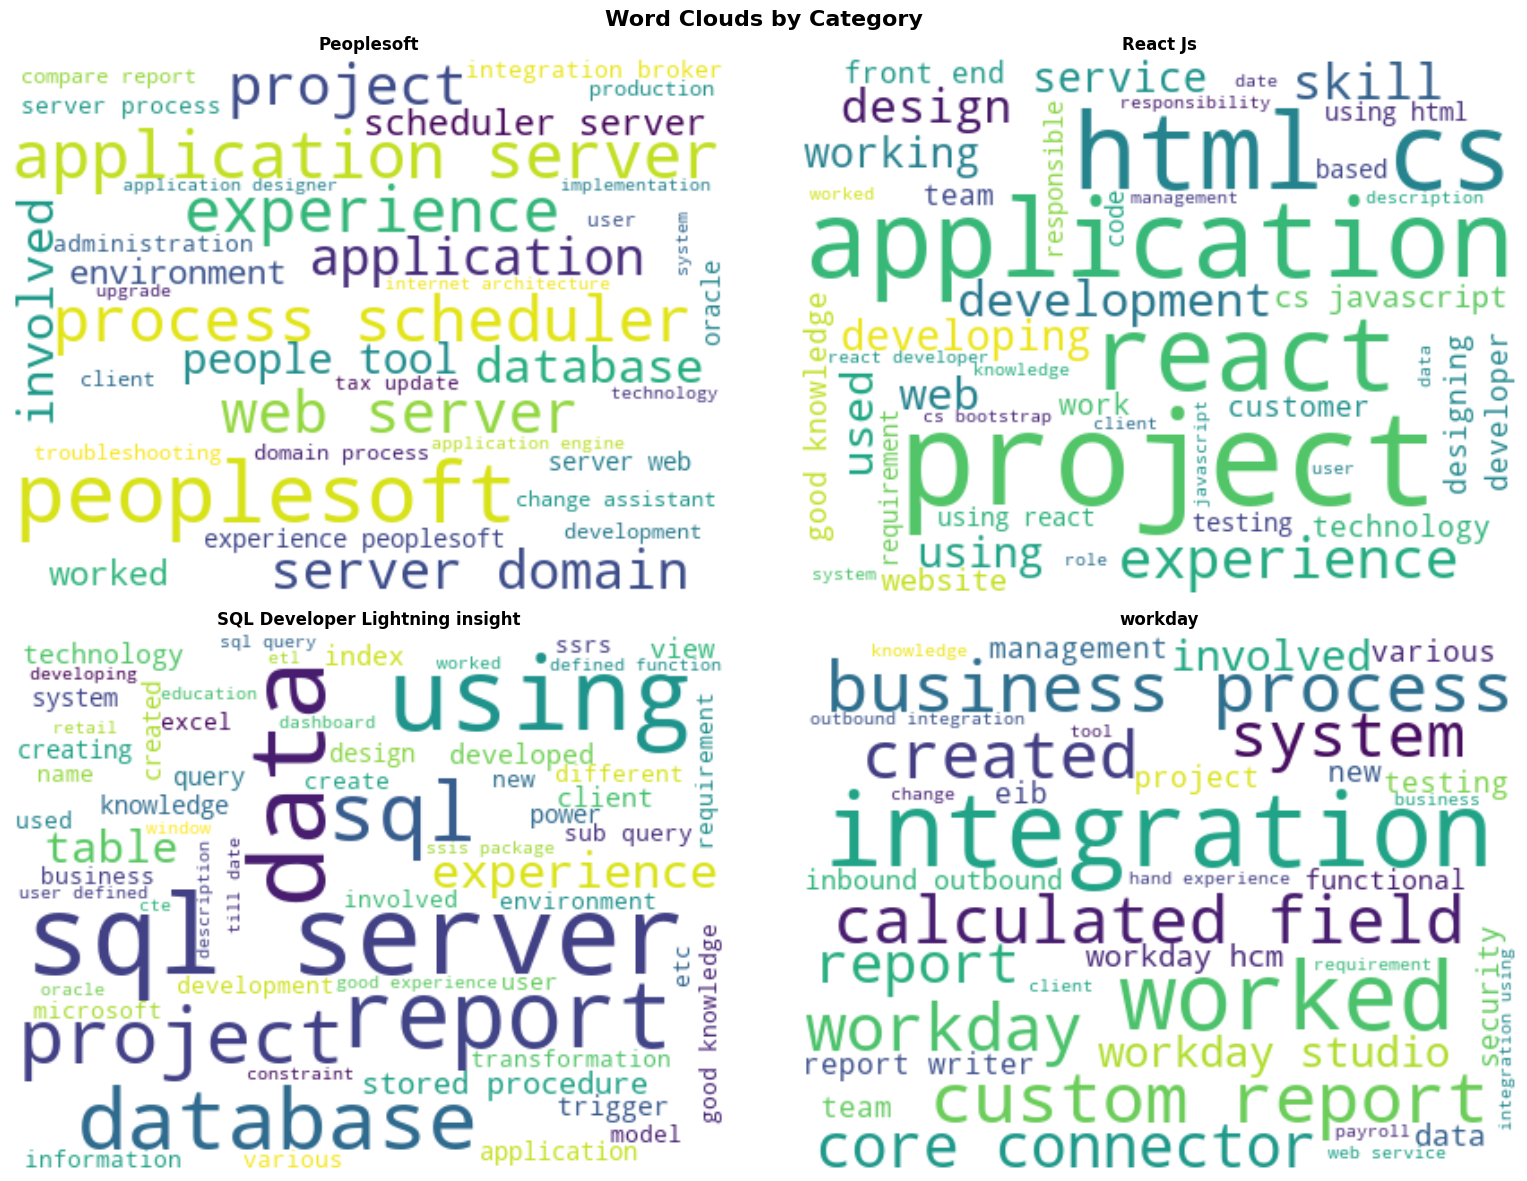

✓ Word cloud analysis complete!


In [150]:
# Generate word clouds for each category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Word Clouds by Category', fontsize=16, fontweight='bold')

for idx, category in enumerate(sorted(df['label'].unique())):
    ax = axes[idx // 2, idx % 2]
    
    # Combine all text for this category
    category_text = ' '.join(df[df['label'] == category]['Cleaned_Details'].values)
    
    # Generate word cloud
    wordcloud = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap='viridis',
        max_words=100,
        min_font_size=10
    ).generate(category_text)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'{category}', fontweight='bold', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("✓ Word cloud analysis complete!")

In [151]:
print("\n" + "="*60)
print("DATA QUALITY REPORT")
print("="*60)

print("\n1. MISSING VALUES:")
print(f"   Total missing: {df.isnull().sum().sum()} ✓")

print("\n2. DUPLICATES:")
duplicates = df.duplicated(subset=['clean_text']).sum()
print(f"   Exact duplicates: {duplicates}")

print("\n3. EMPTY RECORDS:")
empty_count = (df['clean_text'].str.len() == 0).sum()
print(f"   Empty resumes: {empty_count} ✓")

print("\n4. TEXT QUALITY:")
print(f"   Min characters per resume: {df['Text_Length'].min()}")
print(f"   Max characters per resume: {df['Text_Length'].max()}")
print(f"   Avg characters per resume: {df['Text_Length'].mean():.2f}")

print("\n5. CLASS BALANCE:")
class_std = df['label'].value_counts().std()
class_mean = df['label'].value_counts().mean()
imbalance_ratio = class_std / class_mean
print(f"   Std Dev: {class_std:.2f}")
print(f"   Imbalance Ratio: {imbalance_ratio:.2f}")
if imbalance_ratio < 0.3:
    print(f"   Status: ✓ Well-balanced")
elif imbalance_ratio < 0.5:
    print(f"   Status: ⚠️  Moderately balanced")
else:
    print(f"   Status: ✗ Highly imbalanced")

print("\n" + "="*60)
print("SUMMARY: Dataset is ready for model building!")
print("="*60)


DATA QUALITY REPORT

1. MISSING VALUES:
   Total missing: 0 ✓

2. DUPLICATES:
   Exact duplicates: 2

3. EMPTY RECORDS:
   Empty resumes: 0 ✓

4. TEXT QUALITY:
   Min characters per resume: 137
   Max characters per resume: 16742
   Avg characters per resume: 4256.61

5. CLASS BALANCE:
   Std Dev: 4.19
   Imbalance Ratio: 0.21
   Status: ✓ Well-balanced

SUMMARY: Dataset is ready for model building!


In [152]:
# Save processed dataset
output_path = r"C:\Users\sivap\Data Science\Projects\Resumer_Classification"
os.makedirs(output_path, exist_ok=True)

# Save full dataset with all columns
df.to_csv(os.path.join(output_path, 'resume_classification_full.csv'), index=False)

# Save cleaned data only
df[['Cleaned_Details', 'label']].to_csv(
    os.path.join(output_path, 'resume_classification_cleaned.csv'), 
    index=False
)

print(f"✓ Data exported successfully!")
print(f"\nFiles saved to: {output_path}")
print(f"  - resume_classification_full.csv")
print(f"  - resume_classification_cleaned.csv")

✓ Data exported successfully!

Files saved to: C:\Users\sivap\Data Science\Projects\Resumer_Classification
  - resume_classification_full.csv
  - resume_classification_cleaned.csv


In [153]:
df.head()

,filename,resume_text,clean_text,label,Text_Length,Word_Count,Sentence_Count,Cleaned_Details,Cleaned_Length,Cleaned_Word_Count
0,Peoplesoft Admin_AnubhavSingh.docx,Anubhav Kumar Singh\t\t To work in a glob...,anubhav kumar singh to work in a globally comp...,Peoplesoft,6565,901,1,anubhav kumar singh work globally competitive ...,5709,695
1,Peoplesoft Admin_G Ananda Rayudu.docx,\t Profile Summary:\t\t\t\t\t\t\t\t\t\t...,profile summary years of experience in impleme...,Peoplesoft,6681,915,1,profile summary year experience implementing u...,5763,705
2,Peoplesoft Admin_Gangareddy.docx,PeopleSoft Database Administrator ...,peoplesoft database administrator gangareddy p...,Peoplesoft,5547,780,1,peoplesoft database administrator gangareddy p...,4707,569
3,Peoplesoft Admin_Murali.docx,Murali Experience Summary I have 6 years of...,murali experience summary i have years of expe...,Peoplesoft,3682,512,1,murali experience summary year experience work...,3162,391
4,Peoplesoft Admin_Priyanka Ramadoss.docx,"Priyanka Ramadoss 61/46, MountPleasant, Coono...",priyanka ramadoss mountpleasant coonoor the ni...,Peoplesoft,3457,473,1,priyanka ramadoss mountpleasant coonoor nilgir...,2942,344


In [154]:
df.shape

(79, 10)

In [155]:
df['label'].value_counts()

label
React Js                           24
workday                            21
Peoplesoft                         20
SQL Developer Lightning insight    14
Name: count, dtype: int64

In [156]:
import re
# Create lowercase label patterns
labels_to_remove = df['label'].unique()
def remove_label_words(text):
    text = text.lower()    
    for label in labels_to_remove:
        pattern = re.escape(label.lower())
        text = re.sub(pattern, '', text)    
    return text
# Apply cleaning
df['clean_resume'] = df['Cleaned_Details'].apply(remove_label_words)
print("✅ Label keywords removed successfully.")

✅ Label keywords removed successfully.


In [157]:
for i in range(5):
    print("Label:", df['label'].iloc[i])
    print("Before:", df['resume_text'].iloc[i][:150])
    print("After:", df['clean_resume'].iloc[i][:150])
    print("-"*50)

Label: Peoplesoft
Before:   Anubhav Kumar Singh		    To work in a globally competitive environment on    challenging assignments that shall yield the    twin benefits of the jo
After: anubhav kumar singh work globally competitive environment challenging assignment shall yield twin benefit job satisfaction steady paced professional g
--------------------------------------------------
Label: Peoplesoft
Before:       	  Profile Summary:										 7+ years of experience in implementing, upgrading, and supporting PeopleSoft database administration including Hum
After: profile summary year experience implementing upgrading supporting  database administration including human capital management hcm financials campus so
--------------------------------------------------
Label: Peoplesoft
Before: PeopleSoft Database Administrator                                                                                                                     
After:  database administrator gangareddy professio

In [158]:
extra_keywords = [
    "react", "react js", "reactjs",
    "workday",
    "peoplesoft",
    "sql developer",
    "lightning insight"
]

def advanced_clean(text):
    text = text.lower()
    
    for word in extra_keywords:
        text = re.sub(r'\b' + re.escape(word) + r'\b', '', text)
    
    return text

df['clean_resume'] = df['clean_resume'].apply(advanced_clean)

In [159]:
df['clean_resume'].head()

0    anubhav kumar singh work globally competitive ...
1    profile summary year experience implementing u...
2     database administrator gangareddy professiona...
3    murali experience summary year experience work...
4    priyanka ramadoss mountpleasant coonoor nilgir...
Name: clean_resume, dtype: object

In [160]:
for label in df['label'].unique():
    count = df[df['Cleaned_Details'].str.contains(label, case=False, na=False)].shape[0]
    print(f"{label}: {count}")

Peoplesoft: 29
React Js: 0
SQL Developer Lightning insight: 0
workday: 21


In [161]:
from sklearn.preprocessing import LabelEncoder
l_encoder=LabelEncoder()
df['label']=l_encoder.fit_transform(df['label'])

In [162]:
X=df['clean_resume']
y=df['label']

In [163]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # ~ 20% test
    random_state=42,
    stratify=y           # preserve class distribution
)


**NOTE:** If i do the tfidf (feature extraction) before splitting the data it may causes the data leakage problem ,so we have done it after the splitting into train and test .

In [164]:
print("🔍 Extracting TF-IDF features...")
tfidf = TfidfVectorizer(max_features=300, max_df=0.8, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)   # ✅ Only transform
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape: {X_test_tfidf.shape}")

🔍 Extracting TF-IDF features...
Train shape: (63, 300)
Test shape: (16, 300)


In [165]:
# Convert entire matrix to dense NumPy array (careful if it's large)
#X_train_tfidf_matrix_dense = X_train_tfidf.toarray()   # or: X_tfidf.A
#print(tfidf_matrix_dense)

In [166]:
print(X_train_tfidf[0:5].toarray())    # first 5 rows

[[0.01923455 0.02705865 0.06886695 ... 0.02295565 0.06886695 0.0941362 ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.10643505 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.04473296 0.         0.         ... 0.10677392 0.         0.        ]]


In [167]:
X_train_tfidf.shape

(63, 300)

In [168]:
X_test_tfidf.shape

(16, 300)

In [169]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [170]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [171]:
from sklearn.ensemble import RandomForestClassifier

Random_Forest= RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

In [172]:
Random_Forest.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [173]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
y_pred_rf = Random_Forest.predict(X_test_tfidf)
Accuracy= accuracy_score(y_test, y_pred_rf),
Precision= precision_score(y_test, y_pred_rf, average="weighted", zero_division=0),
Recall=    recall_score(y_test, y_pred_rf, average="weighted", zero_division=0),
F1       =f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

In [174]:
print(Accuracy)

(1.0,)


In [175]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [176]:
df.columns

Index(['filename', 'resume_text', 'clean_text', 'label', 'Text_Length',
       'Word_Count', 'Sentence_Count', 'Cleaned_Details', 'Cleaned_Length',
       'Cleaned_Word_Count', 'clean_resume'],
      dtype='object')

In [177]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [178]:
# Step 3: Train SVM model
model = LinearSVC()
model.fit(X_train_tfidf, y_train)

# Step 4: Predict
y_pred = model.predict(X_test_tfidf)

# Step 5: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [179]:
df['label'].value_counts()


label
1    24
3    21
0    20
2    14
Name: count, dtype: int64

In [180]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9375
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      0.80      0.89         5
           2       1.00      1.00      1.00         3
           3       0.80      1.00      0.89         4

    accuracy                           0.94        16
   macro avg       0.95      0.95      0.94        16
weighted avg       0.95      0.94      0.94        16



In [181]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 1.0000
SVM: 1.0000
Random Forest: 1.0000
Naive Bayes: 0.9375


In [185]:

# =============================
# Stratified KFold
# =============================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Important Fix: Prevent NaN
f1_macro = make_scorer(
    f1_score,
    average='macro',
    zero_division=0
)

# =============================
# Model Dictionary
# =============================
models = {
    "Linear SVM": LinearSVC(C=1.0),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# =============================
# Evaluate Models
# =============================
results = []

for name, model in models.items():
    
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=300,
            ngram_range=(1, 2),
            stop_words='english'
        )),
        ("classifier", model)
    ])
    
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=skf,
        scoring=f1_macro,
        error_score='raise'   # exposes hidden errors
    )
    
    results.append({
        "Model": name,
        "Mean Macro F1": round(np.mean(scores), 4),
        "Std Dev": round(np.std(scores), 4)
    })

# =============================
# Results Table
# =============================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Mean Macro F1", ascending=False)

print(results_df)

                 Model  Mean Macro F1  Std Dev
1  Logistic Regression         0.9883   0.0234
3        Random Forest         0.9766   0.0286
2          Naive Bayes         0.9766   0.0286
0           Linear SVM         0.9702   0.0366
4                  KNN         0.9647   0.0446



**I Select Logistic regression**
## 🔎 Why Logistic Regression?
  
 1️⃣ Highest Mean Macro F1

 0.9883 (best among all)

 2️⃣ Lowest Standard Deviation

 0.0234 → Most stable across folds

 3️⃣ Best Model for Small Text Dataset

 For:

 Small sample size (70)

 High-dimensional sparse TF-IDF

 Multi-class classification

 Linear probabilistic models are ideal.

❌ Why Not Random Forest?
* Random Forest Performs well, but:
  * Trees are not ideal for sparse text data
  * More prone to overfitting small datasets
  * Less interpretable in NLP context

❌ Why Not KNN?
* K-Nearest Neighbors
  * Distance-based
  * Performs poorly in high-dimensional space (curse of dimensionality)

❌ Why Not Naive Bayes?
* Naive Bayes classifier
  * Strong baseline
  * But assumes feature independence
  * Logistic Regression generally outperforms it when enough data

🤔 What About Linear SVM?
* Support Vector Machine
  * Normally, SVM is the gold standard in text classification.
  * But in my case:
    * Slightly lower performance
    * Higher variance than Logistic Regression

So Logistic Regression wins statistically.

In [187]:
from sklearn.model_selection import GridSearchCV
import joblib


In [189]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=300,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ("classifier", LogisticRegression(max_iter=1000))
])
param_grid = {
    "classifier__C": [0.1, 0.5, 1, 2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X, y)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", round(grid.best_score_, 4))

Best Parameters: {'classifier__C': 0.5}
Best CV Score: 0.9733


In [190]:
best_model = grid.best_estimator_

In [191]:
joblib.dump(best_model, "resume_classifier_tuned.pkl")

print("Tuned model saved successfully.")

Tuned model saved successfully.
